churn_status
Churned                    59.321108
Active / Not Observable    40.678892
Name: proportion, dtype: float64
Revenue at risk: 7,735,155.87
Revenue at risk %: 58.50%


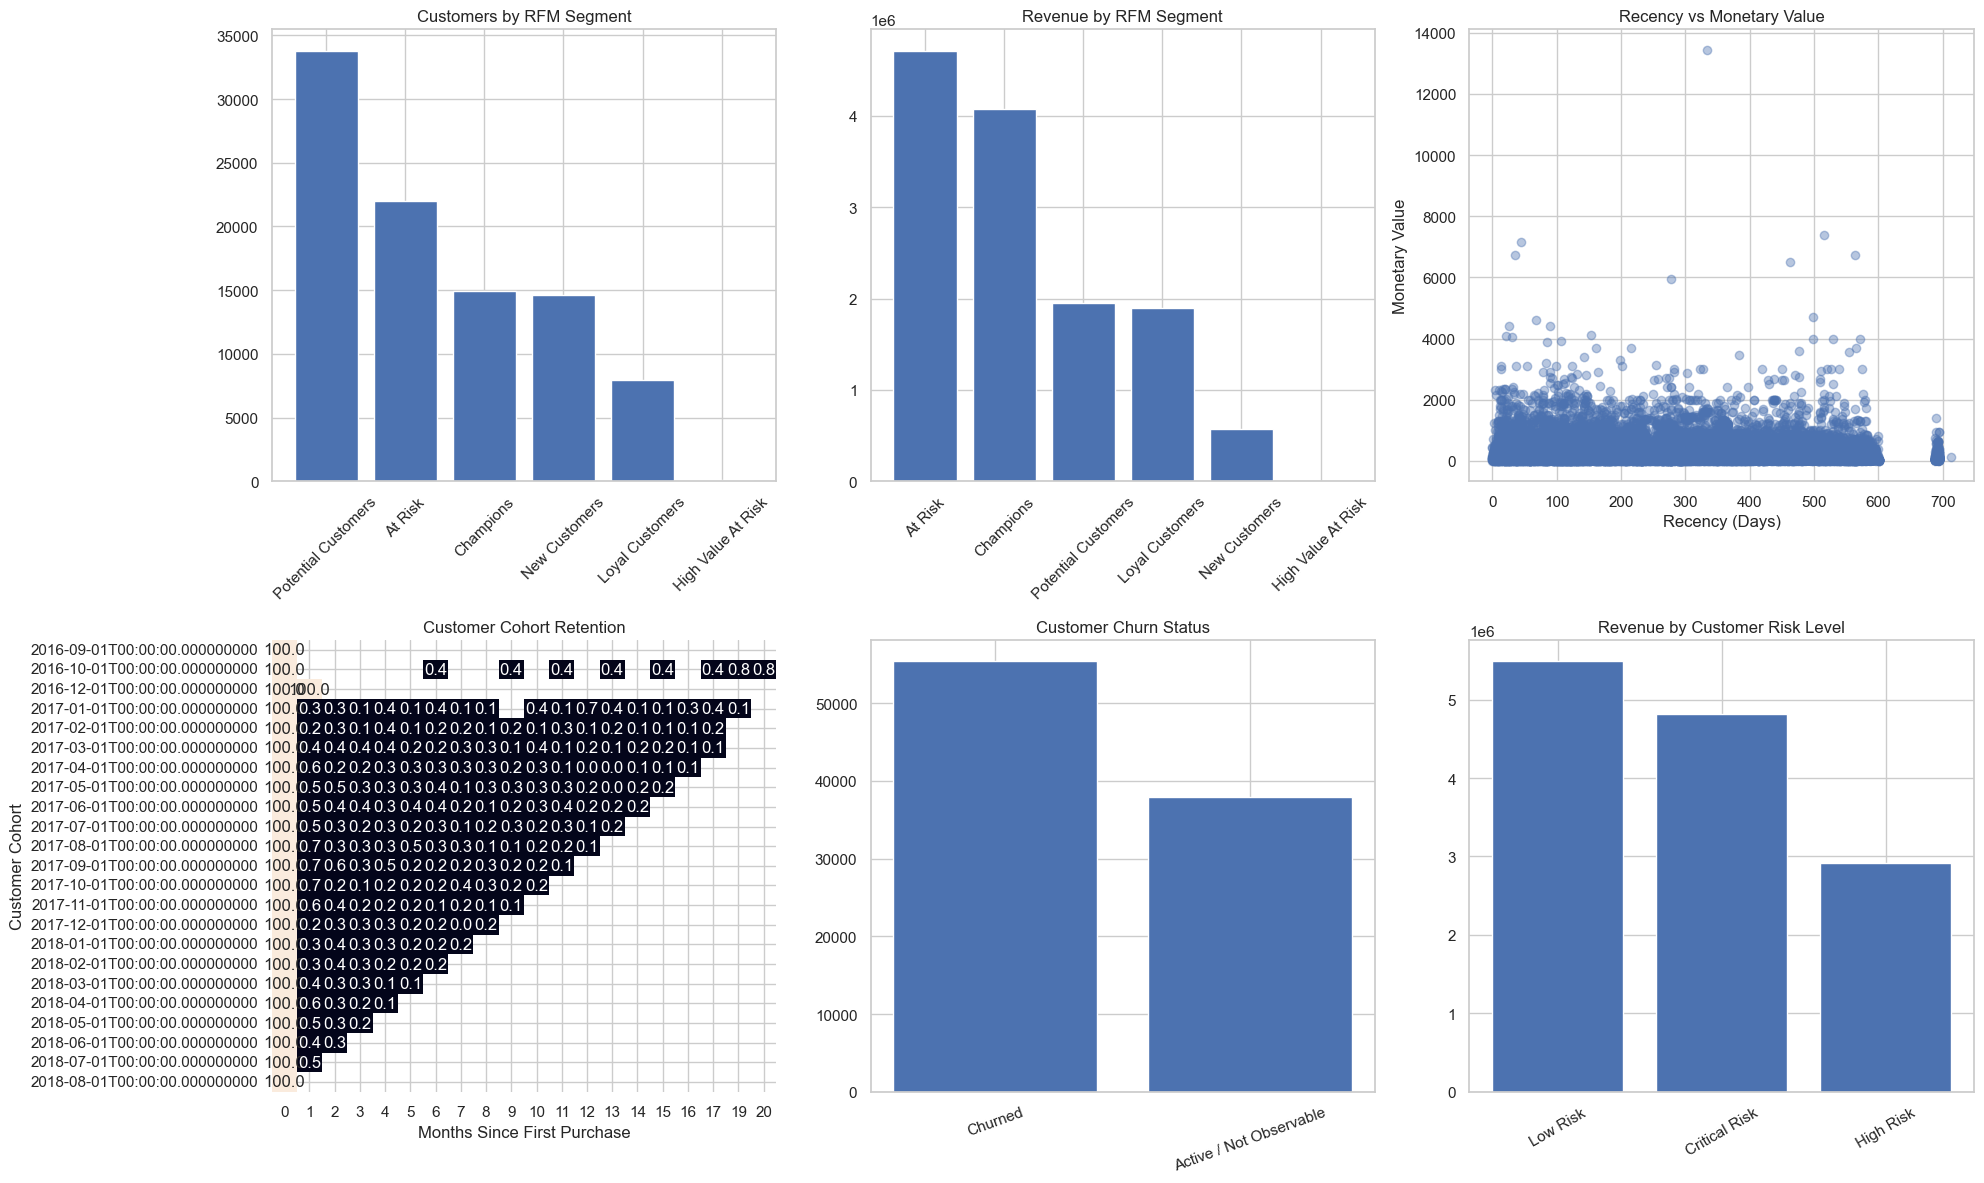

,Metric,Value
0,Total Customers,9.335800e+04
1,Total RFM Revenue,1.322150e+07
2,RFM Segments,6.000000e+00
3,Churned Customers,5.538100e+04
4,Revenue at Risk,7.735156e+06
5,Revenue at Risk %,5.850438e+01


In [1]:
# Step 6.16-6.30: RFM, retention, churn, and customer risk analysis
import os
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from sqlalchemy import create_engine
from dotenv import load_dotenv

load_dotenv()
DB_USER = os.getenv("POSTGRES_USER", "postgres")
DB_PASSWORD = os.getenv("POSTGRES_PASSWORD")
DB_HOST = os.getenv("POSTGRES_HOST", "localhost")
DB_PORT = os.getenv("POSTGRES_PORT", "5432")
DB_NAME = os.getenv("POSTGRES_DB")

if not DB_PASSWORD or not DB_NAME:
    raise RuntimeError(
        "Set POSTGRES_PASSWORD and POSTGRES_DB before running this notebook."
    )

engine = create_engine(
    "postgresql+psycopg2://"
    f"{DB_USER}:{DB_PASSWORD}@{DB_HOST}:{DB_PORT}/{DB_NAME}"
)

customer_rfm = pd.read_sql_query("SELECT * FROM vw_rfm_segments", engine)
cohort_retention = pd.read_sql_query("SELECT * FROM vw_cohort_retention", engine)
customer_churn = pd.read_sql_query("SELECT * FROM vw_customer_churn", engine)
customer_risk = pd.read_sql_query("SELECT * FROM vw_customer_risk", engine)

rfm_summary = (
    customer_rfm.groupby("rfm_segment")
    .agg(
        customers=("customer_unique_id", "count"),
        revenue=("monetary", "sum"),
        avg_recency=("recency", "mean"),
        avg_frequency=("frequency", "mean"),
    )
    .reset_index()
    .sort_values("revenue", ascending=False)
)

cohort_retention["cohort_month"] = pd.to_datetime(cohort_retention["cohort_month"])
retention_matrix = cohort_retention.pivot(
    index="cohort_month",
    columns="cohort_month_number",
    values="retention_rate",
)

churn_percentage = customer_churn["churn_status"].value_counts(normalize=True) * 100
risk_summary = (
    customer_risk.groupby("risk_level")
    .agg(customers=("customer_unique_id", "count"), revenue=("monetary", "sum"))
    .reset_index()
)

high_risk = customer_risk[customer_risk["risk_level"].isin(["Critical Risk", "High Risk"])]
revenue_at_risk = high_risk["monetary"].sum()
total_customer_revenue = customer_risk["monetary"].sum()
revenue_at_risk_pct = revenue_at_risk / total_customer_revenue * 100

print(churn_percentage)
print(f"Revenue at risk: {revenue_at_risk:,.2f}")
print(f"Revenue at risk %: {revenue_at_risk_pct:.2f}%")

sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(2, 3, figsize=(20, 12))

segment_counts = customer_rfm["rfm_segment"].value_counts()
axes[0, 0].bar(segment_counts.index, segment_counts.values)
axes[0, 0].set_title("Customers by RFM Segment")
axes[0, 0].tick_params(axis="x", rotation=45)

axes[0, 1].bar(rfm_summary["rfm_segment"], rfm_summary["revenue"])
axes[0, 1].set_title("Revenue by RFM Segment")
axes[0, 1].tick_params(axis="x", rotation=45)

axes[0, 2].scatter(customer_rfm["recency"], customer_rfm["monetary"], alpha=0.4)
axes[0, 2].set_title("Recency vs Monetary Value")
axes[0, 2].set_xlabel("Recency (Days)")
axes[0, 2].set_ylabel("Monetary Value")

sns.heatmap(retention_matrix, annot=True, fmt=".1f", ax=axes[1, 0], cbar=False)
axes[1, 0].set_title("Customer Cohort Retention")
axes[1, 0].set_xlabel("Months Since First Purchase")
axes[1, 0].set_ylabel("Customer Cohort")

churn_counts = customer_churn["churn_status"].value_counts()
axes[1, 1].bar(churn_counts.index, churn_counts.values)
axes[1, 1].set_title("Customer Churn Status")
axes[1, 1].tick_params(axis="x", rotation=20)

risk_revenue = customer_risk.groupby("risk_level")["monetary"].sum().sort_values(
    ascending=False
)
axes[1, 2].bar(risk_revenue.index, risk_revenue.values)
axes[1, 2].set_title("Revenue by Customer Risk Level")
axes[1, 2].tick_params(axis="x", rotation=30)

plt.tight_layout()
plt.show()

processed_dir = Path("../data/processed")
processed_dir.mkdir(parents=True, exist_ok=True)
customer_rfm.to_csv(processed_dir / "customer_rfm.csv", index=False)
customer_risk.to_csv(processed_dir / "customer_risk.csv", index=False)

summary_df = pd.DataFrame(
    {
        "Metric": [
            "Total Customers",
            "Total RFM Revenue",
            "RFM Segments",
            "Churned Customers",
            "Revenue at Risk",
            "Revenue at Risk %",
        ],
        "Value": [
            customer_rfm["customer_unique_id"].nunique(),
            customer_rfm["monetary"].sum(),
            customer_rfm["rfm_segment"].nunique(),
            (customer_churn["churn_status"] == "Churned").sum(),
            revenue_at_risk,
            revenue_at_risk_pct,
        ],
    }
)
summary_df